# DecoupleR

Test DecoupleR annotation

In [8]:
import scanpy as sc
import decoupler as dc
import pandas as pd
import anndata as ad

# 1. Load Single Cell Data
adata = ad.io.read_h5ad('../data/humancellatlas/5f29c29a-51c6-435c-8ff0-2b2a9d05ebee/BL_standard_design.h5ad')

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Limit adata for tests to 5.000
adata = adata[:5000]

print(adata)

View of AnnData object with n_obs × n_vars = 5000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [9]:
# Load marker genes
marker_df = dc.op.resource("PanglaoDB", organism="human")

# Format marker genes
marker_df = marker_df.rename(columns={"cell_type": "source", "genesymbol": "target"})
marker_df = marker_df[["source", "target"]]
marker_df = marker_df.drop_duplicates(subset=['source', 'target'])

print(marker_df.head())

          source  target
                        
0    Hepatocytes    A1CF
1     Germ cells  A2APA5
2  Bergmann glia     A2M
3     Mast cells  A3FIN4
4     Mast cells  A4GALT


In [10]:
import scipy.sparse as sp

# 1. Sicherstellen, dass adata.X im korrekten CSR-Format vorliegt
if not isinstance(adata.X, sp.csr_matrix):
    print("Konvertiere Matrix zu CSR...")
    adata.X = sp.csr_matrix(adata.X)

# 2. Sicherstellen, dass keine NaN-Werte in der Referenzdatenbank sind
# (PanglaoDB hat manchmal leere Zeilen bei den Genen)
marker_df_clean = marker_df.dropna(subset=['source', 'target'])

# 3. Wichtig: Filtere PanglaoDB, sodass NUR Gene übrig bleiben, die AUCH in deinen Daten sind.
# Das verhindert, dass der Algorithmus mit leeren Vektoren abstürzt.
genes_in_data = set(adata.var_names)
marker_df_clean = marker_df_clean[marker_df_clean['target'].isin(genes_in_data)]

print(f"Schnittmenge der Gene: {len(marker_df_clean['target'].unique())} Gene stimmen überein.")

Schnittmenge der Gene: 3877 Gene stimmen überein.


In [8]:
# Checken, was in deinen Single-Cell Daten steht
print("Deine Gen-Namen (Auszug):", adata.var_names[:5].tolist())

# Checken, was in PanglaoDB steht
print("PanglaoDB Gen-Namen (Auszug):", marker_df['target'].head().tolist())

Deine Gen-Namen (Auszug): ['MIR1302-2HG', 'AL627309.1', 'AL627309.3', 'AL627309.4', 'AL669831.2']
PanglaoDB Gen-Namen (Auszug): ['A1CF', 'A2APA5', 'A2M', 'A3FIN4', 'A4GALT']


In [11]:
# 1. Gen-Namen bereinigen (Alles nach dem Punkt entfernen und in Großbuchstaben umwandeln)
# Aus 'AL627309.1' wird 'AL627309'
clean_names = [gene.split('.')[0].upper() for gene in adata.var_names]

# Überschneidungen prüfen, bevor wir die Namen permanent ändern
overlap_test = set(clean_names).intersection(set(marker_df['target']))
print(f"Schnittmenge NACH der Bereinigung: {len(overlap_test)} Gene stimmen überein.")

# 2. Wenn die Schnittmenge jetzt größer als 0 ist, weisen wir die neuen Namen zu
if len(overlap_test) > 0:
    adata.var_names = clean_names
    # Wichtig: Falls es durch das Abschneiden Duplikate gibt (z.B. GEN.1 und GEN.2 werden beide zu GEN),
    # müssen wir diese einzigartig machen, sonst meckert Scanpy.
    adata.var_names_make_unique()
else:
    print("Warnung: Immer noch keine Übereinstimmung. Deine Daten nutzen vermutlich eine ganz andere Nomenklatur.")

Schnittmenge NACH der Bereinigung: 3874 Gene stimmen überein.


In [12]:
# ORA ausführen
# Wir testen, welche Zelltyp-Signaturen in welchen Zellen überrepräsentiert sind
#dc.run_ora(
dc.mt.ora(
    data=adata,
    net=marker_df,
    #source='cell_type',    # Die Spalte mit den Zelltypen im Netzwerk
    #target='genesymbol',   # Die Spalte mit den Genen im Netzwerk
    n_up=300,                        # Top 300 Gene pro Cluster für den Test nutzen
    n_bg=int(adata.shape[1]), # Setzt den Hintergrund exakt auf deine 25825 Gene!
    verbose=True,
    raw=False          # Nutzt adata.X
)

2026-06-09 21:25:03 | [INFO] ora - Running ora
2026-06-09 21:25:04 | [INFO] Extracted omics mat with 5000 rows (observations) and 25825 columns (features)
2026-06-09 21:25:04 | [WARNING] 7483 features of mat are empty, they will be removed
2026-06-09 21:25:04 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-06-09 21:25:04 | [INFO] Network has 2906 unique features and 155 unique sources
2026-06-09 21:25:04 | [INFO] ora - calculating 155 scores across 5000 observations with n_up=300, n_bm=0, n_bg=25825
100%|██████████████████████████████████████████████| 5000/5000 [00:43<00:00, 114.09it/s]
2026-06-09 21:25:47 | [INFO] ora - adjusting p-values by FDR
2026-06-09 21:25:52 | [INFO] ora - done


In [15]:
print(adata)

AnnData object with n_obs × n_vars = 5000 × 25825
    obs: 'n_genes', 'Channel', 'n_counts', 'percent_mito', 'scale', 'Group', 'leiden_labels', 'Donor', 'doublet_score', 'pred_dbl', 'anno'
    var: 'featureid', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'mean', 'var', 'hvf_loess', 'hvf_rank'
    uns: 'Channels', 'Groups', 'PCs', 'W_pca_harmony', 'c2gid', 'df_qcplot', 'genome', 'gncells', 'leiden_resolution', 'modality', 'ncells', 'norm_count', 'pca', 'pca_features', 'pca_harmony_knn_distances', 'pca_harmony_knn_indices', 'stdzn_max_value', 'stdzn_mean', 'stdzn_std', 'log1p'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'score_ora', 'padj_ora'
    varm: 'de_res', 'gmeans', 'gstds', 'means', 'partial_sum'


In [21]:
print(type(adata.obsm['score_ora']))

<class 'pandas.core.frame.DataFrame'>


In [27]:
# Erstellt eine AnnData-Objekt-Kopie nur für die Scores, um sie leichter zu plotten
#acts = dc.get_acts(adata, obsm_key='ora_estimate')
#acts = dc.pp.extract(adata, layer='score_ora')

# Beispiel: Plotten der Aktivität für "T cells" und "B cells" (Namen an deinen Daten anpassen!)
sc.pl.umap(adata.obsm['score_ora'], color=['T cells', 'B cells'], cmap='开放_RdBu_r', vcenter=0)

AttributeError: 'DataFrame' object has no attribute '_sanitize'

/tmp/ipykernel_97407/2856113674.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = df.groupby('cluster').mean()


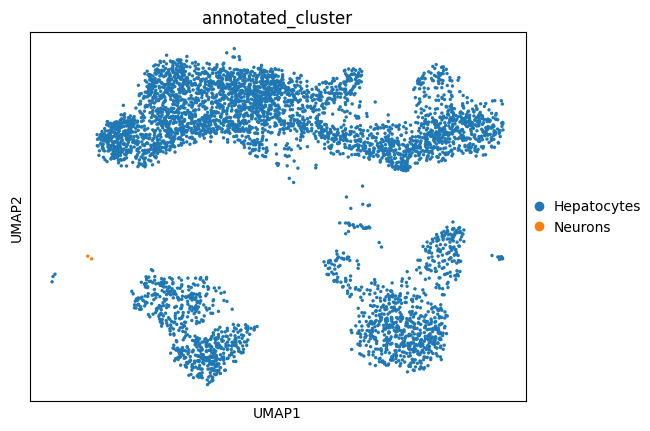

In [23]:
# Berechne den mittleren ORA-Score pro bestehendem Cluster (z.B. 'louvain' oder 'leiden')
#df = dc.get_acts(adata, obsm_key='ora_estimate').to_df()
df = adata.obsm['score_ora']
df['cluster'] = adata.obs['leiden_labels'] # oder 'leiden'
mean_df = df.groupby('cluster').mean()

# Für jeden Cluster den Zelltyp mit dem höchsten mittleren Score finden
cluster_to_celltype = mean_df.idxmax(axis=1).to_dict()

# Map die Annotationen zurück auf die Zellen
adata.obs['annotated_cluster'] = adata.obs['leiden_labels'].map(cluster_to_celltype)

# Finaler Plot
sc.pl.umap(adata, color='annotated_cluster')

In [24]:
classes = set(adata.obs['annotated_cluster'])
print(classes)

{'Neurons', 'Hepatocytes'}


In [26]:
leiden_labels = set(adata.obs['leiden_labels'])
print(leiden_labels)

{'4', '9', '18', '7', '2', '12', '8', '16', '15', '14', '6', '10', '11', '5', '19', '17', '20', '3', '13', '1'}


In [25]:
print(marker_df)

                          source   target
                                         
0                    Hepatocytes     A1CF
1                     Germ cells   A2APA5
2                  Bergmann glia      A2M
3                     Mast cells   A3FIN4
4                     Mast cells   A4GALT
...                          ...      ...
8206  Adipocyte progenitor cells   ZNF521
8207                  Germ cells    ZNRF4
8208                  Germ cells    ZPBP2
8209                     Neurons  ZRSR2P1
8210        Embryonic stem cells  ZSCAN10

[8190 rows x 2 columns]
